In [1]:
import pandas as pd
import os

# 1. Define the path to your file
# We use 'os.path.join' so it works on Windows and Mac automatically
filename = os.path.join("data", "Wednesday-workingHours.pcap_ISCX.csv")

# 2. Check if file exists before loading
if os.path.exists(filename):
    print("File found! Loading dataset... (Please wait, big file)")
    
    # Load the data
    df = pd.read_csv(filename)
    
    print("Success! Dataset loaded.")
    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")
    
    # 3. Show the raw data
    display(df.head())
else:
    print(f"ERROR: Could not find file at {filename}")
    print("Make sure you dragged the csv file into a folder named 'data'!")

File found! Loading dataset... (Please wait, big file)
Success! Dataset loaded.
Rows: 692703
Columns: 79


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


Column names cleaned!

--- Traffic Distribution ---
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


C:\Users\Bakugo\AppData\Local\Temp\ipykernel_28376\3097782731.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


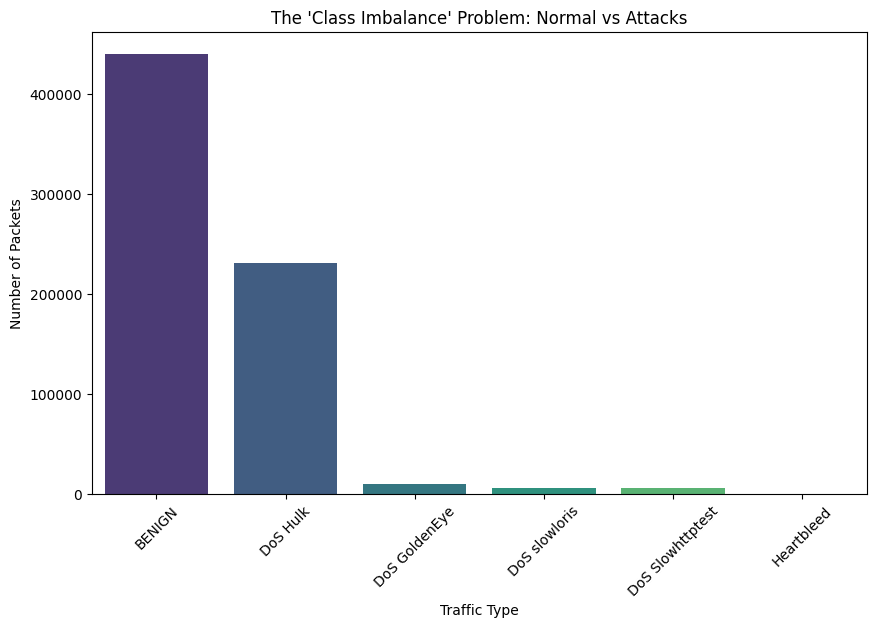

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. FIX THE MESSY COLUMN NAMES
# The dataset has spaces like " Label" instead of "Label". This fixes it instantly.
df.columns = df.columns.str.strip()
print("Column names cleaned!")

# 2. Count how many of each "Label" we have
label_counts = df['Label'].value_counts()
print("\n--- Traffic Distribution ---")
print(label_counts)

# 3. Visualize it (The "Evidence" for your Report)
plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
plt.title("The 'Class Imbalance' Problem: Normal vs Attacks")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Packets")
plt.xticks(rotation=45) # Rotates the names so they don't overlap
plt.show()

In [3]:
# ================================
# DATA CLEANING + LABEL ENCODING
# ================================

import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. HANDLE MISSING / INFINITE VALUES
print(f"Original shape: {df.shape}")

# Replace +inf and -inf with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Count NaN before dropping (for visibility)
total_nan = df.isna().sum().sum()
print(f"Total NaN values before drop: {total_nan}")

# Drop rows with ANY missing values
df.dropna(inplace=True)

print(f"Shape after cleaning: {df.shape} (Junk rows removed!)")


# 2. CONVERT TEXT LABELS TO NUMBERS
# AI models need numeric labels

le = LabelEncoder()

# Encode Label column
df['Label_Encoded'] = le.fit_transform(df['Label'])

print("\nSuccess! Labels converted to numbers.")

# Show mapping for reference (IMPORTANT for interpretation later)
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Label Mapping: {mapping}")


# 3. SEPARATE FEATURES (X) AND TARGET (y)
# X = All feature columns
# y = Encoded attack labels

X = df.drop(columns=['Label', 'Label_Encoded'])
y = df['Label_Encoded']

print("\nData is ready for AI Training!")
print(f"Features (X) shape: {X.shape}")
print(f"Labels (y) shape: {y.shape}")

# Sanity checks
print("\nUnique classes in y:", np.unique(y))
print("Class distribution:\n", y.value_counts())

Original shape: (692703, 79)
Total NaN values before drop: 2594
Shape after cleaning: (691406, 79) (Junk rows removed!)

Success! Labels converted to numbers.
Label Mapping: {'BENIGN': np.int64(0), 'DoS GoldenEye': np.int64(1), 'DoS Hulk': np.int64(2), 'DoS Slowhttptest': np.int64(3), 'DoS slowloris': np.int64(4), 'Heartbleed': np.int64(5)}

Data is ready for AI Training!
Features (X) shape: (691406, 78)
Labels (y) shape: (691406,)

Unique classes in y: [0 1 2 3 4 5]
Class distribution:
 Label_Encoded
0    439683
2    230124
1     10293
4      5796
3      5499
5        11
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. SPLIT THE DATA (80% Training, 20% Testing)
print("Splitting data into Train and Test sets...")
# 'stratify=y' ensures the rare attacks are split evenly between train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# 2. SCALE THE FEATURES
print("\nScaling the features (Standardization)...")
scaler = StandardScaler()

# We 'fit' (learn the min/max) ONLY on the training data to prevent cheating
X_train_scaled = scaler.fit_transform(X_train)
# We apply that same scale to the test data
X_test_scaled = scaler.transform(X_test)

print("Success! Data is split and scaled.")

Splitting data into Train and Test sets...
Training data shape: (553124, 78)
Testing data shape: (138282, 78)

Scaling the features (Standardization)...
Success! Data is split and scaled.


In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Bidirectional, LSTM, MultiHeadAttention, GlobalAveragePooling1D

# 1. RESHAPE DATA TO 3D FOR Bi-LSTM
# Standard ML uses 2D (Rows, Columns). LSTMs need 3D (Rows, TimeSteps, Features).
X_train_3D = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_3D = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

print(f"Old 2D shape: {X_train_scaled.shape}")
print(f"New 3D shape for Deep Learning: {X_train_3D.shape}\n")
print("Building the Hybrid Model Architecture...")

# 2. BUILD THE ARCHITECTURE

# Input Layer
inputs = Input(shape=(X_train_3D.shape[1], X_train_3D.shape[2]))

# Dense Layer: For early feature extraction
x = Dense(64, activation='relu')(inputs)

# Bi-LSTM Layer: Moves forward and backward to catch complex network patterns
x = Bidirectional(LSTM(64, return_sequences=True))(x)

# Multi-Head Attention Layer: The "Innovation" that focuses on critical attack features
attention_out = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)

# Flatten it back down so we can pass it to XGBoost later
features = GlobalAveragePooling1D()(attention_out)

# Create the Model
# Notice we are NOT classifying yet. We are just building the "Feature Extractor" 
feature_extractor_model = Model(inputs=inputs, outputs=features)

# Show the blueprint
feature_extractor_model.summary()
print("\nSuccess! Deep Learning Architecture Built.")

Old 2D shape: (553124, 78)
New 3D shape for Deep Learning: (553124, 1, 78)

Building the Hybrid Model Architecture...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1, 78)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 64)     │      5,056 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 1, 128)    │     66,048 │ dense[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 128)    │    131,968 │ bidirectional[0]… │
│ (MultiHeadAttentio… │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 203,072 (793.25 KB)

 Trainable params: 203,072 (793.25 KB)

 Non-trainable params: 0 (0.00 B)


Success! Deep Learning Architecture Built.


In [6]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. ATTACH A TEMPORARY CLASSIFIER TO TRAIN THE DL MODEL
# We need to teach the DL model how to extract good features first.
num_classes = len(np.unique(y))
outputs = Dense(num_classes, activation='softmax')(feature_extractor_model.output)
full_dl_model = Model(inputs=feature_extractor_model.input, outputs=outputs)

# Compile the model (Matching the base paper settings)
full_dl_model.compile(optimizer='adam', 
                      loss='sparse_categorical_crossentropy', 
                      metrics=['accuracy'])

print("Training the Deep Learning feature extractor (This will take a few minutes)...")
# We use 1 epoch and a large batch_size to keep it fast for your laptop
full_dl_model.fit(X_train_3D, y_train, epochs=1, batch_size=256, validation_split=0.1)


# 2. EXTRACT THE OPTIMIZED FEATURES
# Now that the DL model is smart, we strip off the temporary classifier 
# and use it just to pull out the 128 best features from the Attention layer.
print("\nExtracting deep features for XGBoost...")
X_train_features = feature_extractor_model.predict(X_train_3D, batch_size=256)
X_test_features = feature_extractor_model.predict(X_test_3D, batch_size=256)


# 3. TRAIN THE XGBOOST CLASSIFIER
# XGBoost is extremely fast and accurate at making the final decision.
print("\nTraining the XGBoost Classifier on the Deep Features...")
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train_features, y_train)


# 4. FINAL EVALUATION
print("\nTesting the Hybrid Model...")
y_pred = xgb_model.predict(X_test_features)

# Print the results
acc = accuracy_score(y_test, y_pred)
print("========================================")
print(f"HYBRID MODEL FINAL ACCURACY: {acc * 100:.2f}%")
print("========================================")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Training the Deep Learning feature extractor (This will take a few minutes)...
1945/1945 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - accuracy: 0.9830 - loss: 0.0531 - val_accuracy: 0.9887 - val_loss: 0.0317

Extracting deep features for XGBoost...
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
541/541 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Training the XGBoost Classifier on the Deep Features...


c:\Users\Bakugo\Desktop\Capstone_IDS\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:28:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Testing the Hybrid Model...
HYBRID MODEL FINAL ACCURACY: 99.93%

Detailed Classification Report:
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00     87937
   DoS GoldenEye       0.99      0.99      0.99      2059
        DoS Hulk       1.00      1.00      1.00     46025
DoS Slowhttptest       0.99      0.99      0.99      1100
   DoS slowloris       0.99      0.99      0.99      1159
      Heartbleed       1.00      1.00      1.00         2

        accuracy                           1.00    138282
       macro avg       0.99      1.00      0.99    138282
    weighted avg       1.00      1.00      1.00    138282

